In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# File
chemin_fichier = "../data/raw/CO2 Emissions_Canada.xls"

# Read file
df_vehicules = pd.read_csv(chemin_fichier)

# Display file
display(df_vehicules.head())



X = df_vehicules[['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']]
y = df_vehicules['CO2 Emissions(g/km)'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modele_co2 = LinearRegression() 
modele_co2.fit(X_train, y_train) # L'IA apprend en regardant les 80% de données !

predictions = modele_co2.predict(X_test) # On lui demande de prédire le CO2 des 20% restants
precision = r2_score(y_test, predictions) # On compare ses réponses avec la réalité

print(f"L'entraînement est terminé !")
print(f"Précision du modèle (Score R²) : {precision * 100:.2f} %")

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


L'entraînement est terminé !
Précision du modèle (Score R²) : 87.73 %


Saved!


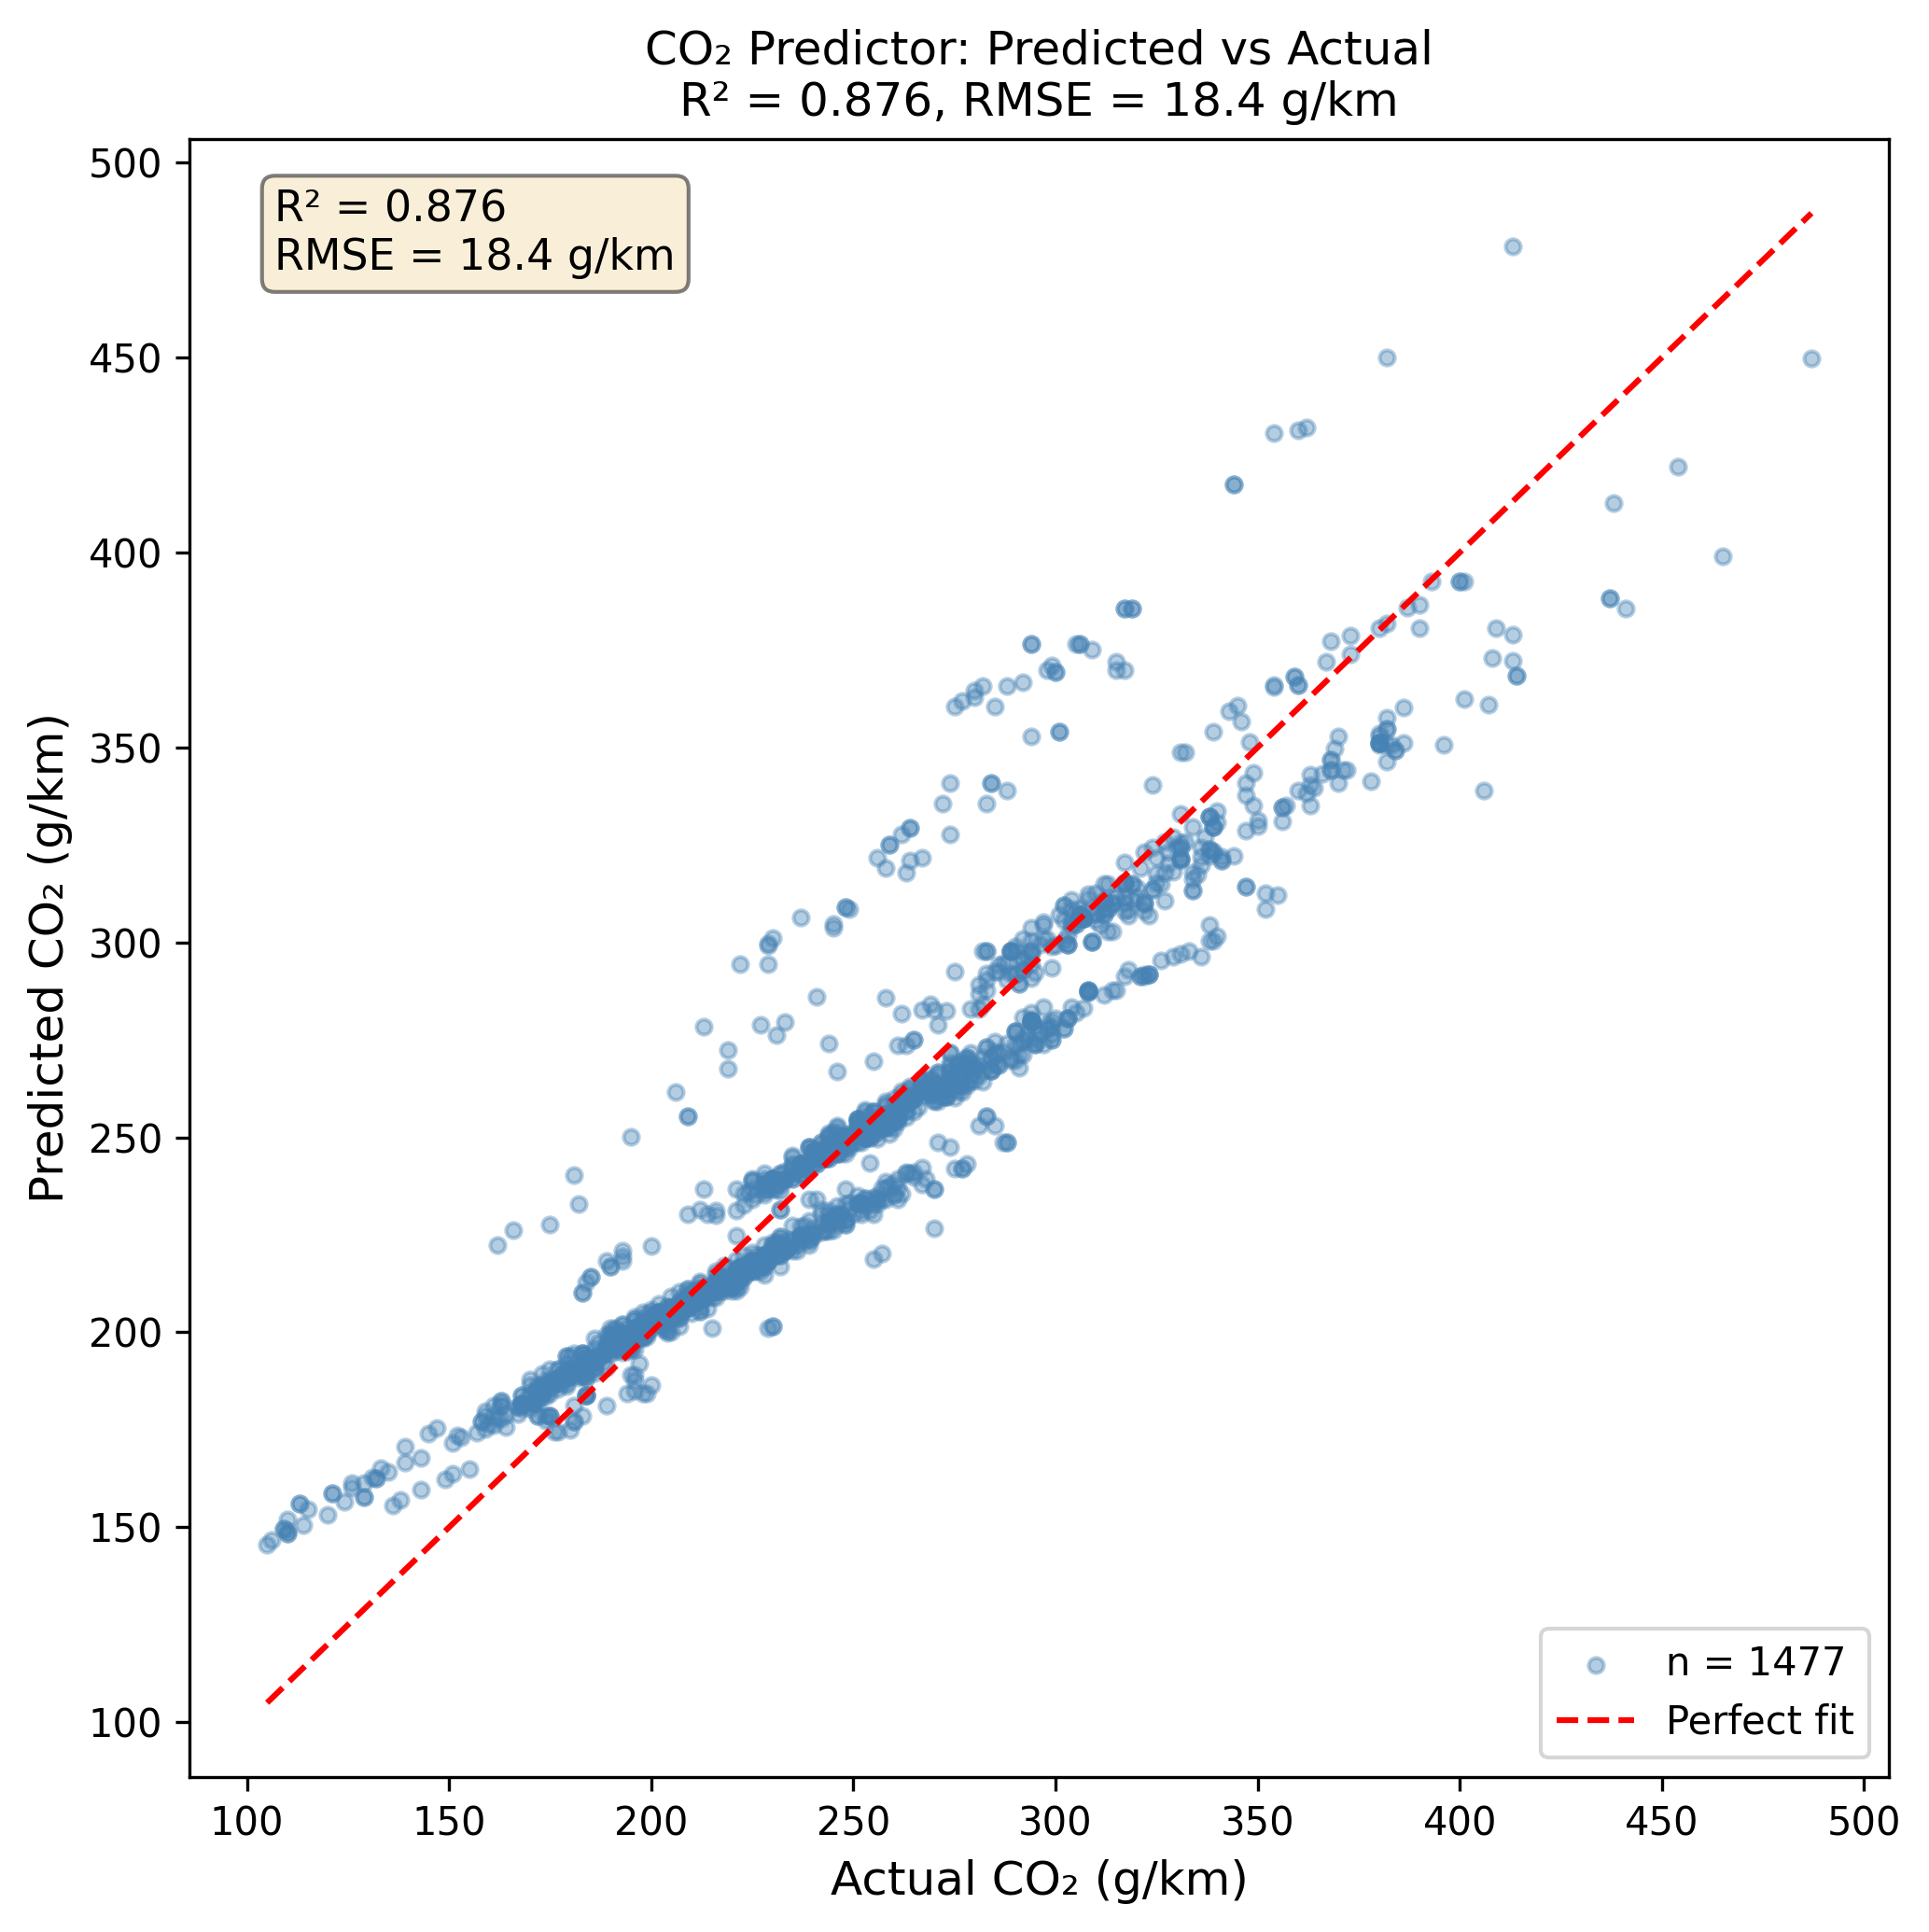

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Recharge le dataset et le modèle (adapte le chemin)
df = pd.read_csv('../data/raw/CO2 Emissions_Canada.xls')
df = df.dropna(subset=['Engine Size(L)', 'Cylinders',
                        'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)'])

X = df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']]
y = df['CO2 Emissions(g/km)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7), dpi=300)
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue', label=f'n = {len(y_test)}')

# Ligne diagonale parfaite
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')

ax.set_xlabel('Actual CO₂ (g/km)', fontsize=12)
ax.set_ylabel('Predicted CO₂ (g/km)', fontsize=12)
ax.set_title(f'CO₂ Predictor: Predicted vs Actual\nR² = 0.876, RMSE = 18.4 g/km', fontsize=12)
ax.legend(fontsize=10)
ax.text(0.05, 0.92, 'R² = 0.876\nRMSE = 18.4 g/km',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figure3_co2_scatter.png', dpi=300, bbox_inches='tight')
print("Saved!")